In [8]:
# ============================================================
# AI vs Human Text Detection
# Install Required Libraries
# ============================================================

!pip install -q transformers datasets accelerate
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 102.9 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [9]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

import torch
import torchvision
import datasets
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
import random

In [10]:
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

Transformers: 5.0.0
Datasets: 4.8.5
Torch: 2.10.0+cu128
TorchVision: 0.25.0+cu128


In [11]:
# ============================================================
# Set Random Seeds
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed Set Successfully")

Seed Set Successfully


In [12]:
# ==========================================
# Check GPU Availability
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Using Device: cuda
GPU Name: Tesla T4


In [13]:
# ============================================================
# Load AI Text Detection Dataset
# ============================================================

dataset = load_dataset(
    "artem9k/ai-text-detection-pile"
)

print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007-bc5952582e004d(…):   0%|          | 0.00/758M [00:00<?, ?B/s]

data/train-00001-of-00007-71c80017bc45f3(…):   0%|          | 0.00/318M [00:00<?, ?B/s]

data/train-00002-of-00007-ee2d43f396e78f(…):   0%|          | 0.00/125M [00:00<?, ?B/s]

data/train-00003-of-00007-529931154b42b5(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

data/train-00004-of-00007-b269dc49374a2c(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

data/train-00005-of-00007-3dce5e05ddbad7(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

data/train-00006-of-00007-3d8a471ba0cf1c(…):   0%|          | 0.00/242M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1392522 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['source', 'id', 'text'],
        num_rows: 1392522
    })
})


In [14]:
# ============================================================
# Convert Dataset to Pandas DataFrame
# ============================================================

df = dataset["train"].to_pandas()
print("Shape:", df.shape)
df.head()

Shape: (1392522, 3)


,source,id,text
0,human,0,12 Years a Slave: An Analysis of the Film Essa...
1,human,1,20+ Social Media Post Ideas to Radically Simpl...
2,human,2,2022 Russian Invasion of Ukraine in Global Med...
3,human,3,533 U.S. 27 (2001) Kyllo v. United States: The...
4,human,4,A Charles Schwab Corporation Case Essay\n\nCha...


In [15]:
# ============================================================
# Dataset Exploration
# ============================================================

print(df.columns)
print("\nSource Distribution:")
print(df["source"].value_counts())

Index(['source', 'id', 'text'], dtype='object')

Source Distribution:
source
human    1028146
ai        364376
Name: count, dtype: int64


In [16]:
# ============================================================
# Convert Labels to Numeric Format
# ============================================================
# human -> 0
# ai -> 1

label_map = {"human": 0, "ai": 1}
df["label"] = df["source"].map(label_map)
print(df["label"].value_counts())

label
0    1028146
1     364376
Name: count, dtype: int64


In [17]:
# ============================================================
# Create Balanced Dataset
# ============================================================

human_df = df[df["label"] == 0].sample(30000, random_state=SEED)

ai_df = df[df["label"] == 1].sample(30000, random_state=SEED)

balanced_df = pd.concat([human_df, ai_df])

balanced_df = balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(balanced_df.shape)

print(balanced_df["label"].value_counts())

(60000, 4)
label
0    30000
1    30000
Name: count, dtype: int64


In [18]:
# ============================================================
# Basic Text Cleaning
# ============================================================

balanced_df = balanced_df.dropna(subset=["text"])

balanced_df["text"] = (balanced_df["text"].astype(str).str.strip())

balanced_df = balanced_df[balanced_df["text"].str.len() > 0]

balanced_df = balanced_df[balanced_df["text"].apply(
        lambda x: len(x.split()) > 20
    )]

balanced_df = balanced_df.reset_index(drop=True)

print("Final Shape:")
print(balanced_df.shape)

Final Shape:
(59111, 4)


In [19]:
# ============================================================
# Train Validation Test Split
# ============================================================

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    balanced_df["text"],
    balanced_df["label"],
    test_size=0.2,
    random_state=SEED,
    stratify=balanced_df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

Training Samples: 47288
Validation Samples: 5911
Test Samples: 5912


In [20]:
#-------------------------------------------
# LOAD TOKENIZER
#-------------------------------------------
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [21]:
print(type(tokenizer))
print(tokenizer.name_or_path)

<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
distilbert-base-uncased


In [22]:
# ============================================================
# Custom PyTorch Dataset
# ============================================================

MAX_LENGTH = 128
class AITextDataset(Dataset):
    def __init__(
        self,
        texts,
        labels,
        tokenizer
    ):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH, return_tensors="pt")

        return {

            "input_ids":
                encoding["input_ids"].squeeze(0),

            "attention_mask":
                encoding["attention_mask"].squeeze(0),

            "labels":
                torch.tensor(
                    self.labels[idx],
                    dtype=torch.long
                )
        }

In [23]:
# ==========================================
# Creating dataset objects
# ==========================================

train_dataset = AITextDataset(
    train_texts,
    train_labels,
    tokenizer
)

val_dataset = AITextDataset(
    val_texts,
    val_labels,
    tokenizer
)

test_dataset = AITextDataset(
    test_texts,
    test_labels,
    tokenizer
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

47288
5911
5912


In [24]:
# ==========================================
# Creating Data Loaders
# ==========================================
BATCH_SIZE = 16
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [25]:
# ============================================================
# Verify DataLoader
# ============================================================

batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16])


In [26]:
# ==========================================
# Load DistilBert Model
# ==========================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [27]:
# ============================================================
# Optimizer
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)

print("Optimizer Ready")

Optimizer Ready


In [28]:
# ============================================================
# Validation Function
# ============================================================

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    return (
        avg_loss,
        accuracy,
        precision,
        recall,
        f1
    )

In [29]:
# ==========================================
# Training Loop
# ==========================================

EPOCHS = 2

train_losses = []
val_losses = []

best_f1 = 0
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader)
    for batch in progress_bar:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
        progress_bar.set_postfix(
            {"loss": loss.item()}
        )

    avg_train_loss = (total_train_loss / len(train_loader))
    train_losses.append(avg_train_loss)

    (
        val_loss,
        val_acc,
        val_precision,
        val_recall,
        val_f1
    ) = evaluate_model(
        model,
        val_loader
    )

    val_losses.append(val_loss)

    print(f"Train Loss: {avg_train_loss:.4f}")

    print(f"Val Loss: {val_loss:.4f}")

    print(f"Val Accuracy: {val_acc:.4f}")

    print(f"Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_distilbert_ai_detector.pt")
        print("Best model saved.")


Epoch 1/2


100%|██████████| 2956/2956 [11:04<00:00,  4.45it/s, loss=0.0353] 


Train Loss: 0.1675
Val Loss: 0.1106
Val Accuracy: 0.9555
Val F1: 0.9558
Best model saved.

Epoch 2/2


100%|██████████| 2956/2956 [11:16<00:00,  4.37it/s, loss=0.0711]  


Train Loss: 0.0604
Val Loss: 0.1543
Val Accuracy: 0.9494
Val F1: 0.9509


In [30]:
# ==========================================
# Load Best Model
# ==========================================

model.load_state_dict(
    torch.load(
        "best_distilbert_ai_detector.pt"
    )
)
print("Best Model Loaded")

Best Model Loaded


In [31]:
torch.save(
    model.state_dict(),
    "best_distilbert_ai_detector.pt"
)

In [32]:
SAVE_PATH = "ai_text_detector_model"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('ai_text_detector_model/tokenizer_config.json',
 'ai_text_detector_model/tokenizer.json')

In [33]:
# ==========================================
# Model Evaluation
# ==========================================

test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate_model(model, test_loader)

print("\nTEST RESULTS")

print("Accuracy :", test_acc)
print(f"Loss: {test_loss:.4f}")
print("Precision:", test_prec)
print("Recall   :", test_rec)
print("F1 Score :", test_f1)


TEST RESULTS
Accuracy : 0.9539918809201624
Loss: 0.1201
Precision: 0.9313597918022121
Recall   : 0.9791381668946648
F1 Score : 0.9546515505168389


In [34]:
# ==========================================
# Generate Predictions
# ==========================================

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

100%|██████████| 370/370 [00:30<00:00, 12.25it/s]


In [35]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(all_labels, all_preds, target_names=["Human", "AI"]))

              precision    recall  f1-score   support

       Human       0.98      0.93      0.95      2988
          AI       0.93      0.98      0.95      2924

    accuracy                           0.95      5912
   macro avg       0.95      0.95      0.95      5912
weighted avg       0.96      0.95      0.95      5912



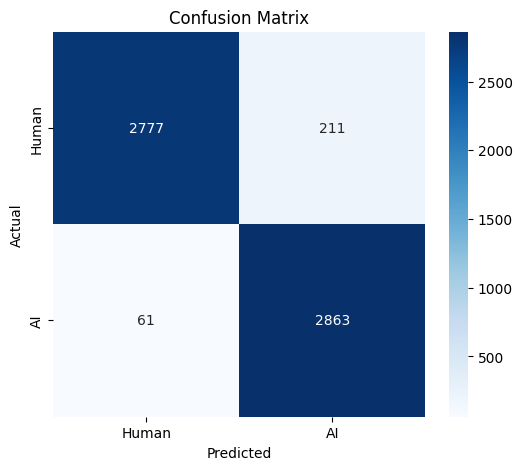

In [36]:
#===============================================
# Confusion Matrix
#===============================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human","AI"],
    yticklabels=["Human","AI"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [37]:
#======================================================
#Predictions On Custom Data
#======================================================
import torch
import torch.nn.functional as F

def predict_text(text):

    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = F.softmax(
            outputs.logits,
            dim=1
        )

    human_prob = probs[0][0].item()
    ai_prob = probs[0][1].item()

    prediction = torch.argmax(
        probs,
        dim=1
    ).item()

    label = (
        "AI Generated"
        if prediction == 1
        else "Human Written"
    )

    confidence = max(
        human_prob,
        ai_prob
    ) * 100

    print("="*60)
    print("Prediction :", label)
    print(f"Confidence : {confidence:.2f}%")
    print(f"Human Prob : {human_prob:.4f}")
    print(f"AI Prob    : {ai_prob:.4f}")
    print("="*60)

    return {
        "prediction": label,
        "confidence": confidence,
        "human_prob": human_prob,
        "ai_prob": ai_prob
    }

In [38]:
human_text_1 = """
The Taj Mahal is an ivory-white marble mausoleum located in Agra, India.
It was commissioned in 1632 by the Mughal emperor Shah Jahan in memory
of his wife Mumtaz Mahal. The monument is widely regarded as one of the
finest examples of Mughal architecture and attracts millions of visitors
every year.
"""

predict_text(human_text_1)

Prediction : AI Generated
Confidence : 96.94%
Human Prob : 0.0306
AI Prob    : 0.9694


{'prediction': 'AI Generated',
 'confidence': 96.93776369094849,
 'human_prob': 0.03062240034341812,
 'ai_prob': 0.9693776369094849}

In [39]:
ai_text_1 = """
Artificial intelligence is revolutionizing industries across the globe
by enabling organizations to automate processes, improve efficiency,
and gain deeper insights from data. Businesses that adopt AI-driven
strategies are often better positioned to innovate and remain competitive
in rapidly changing markets.
"""

predict_text(ai_text_1)

Prediction : AI Generated
Confidence : 63.01%
Human Prob : 0.3699
AI Prob    : 0.6301


{'prediction': 'AI Generated',
 'confidence': 63.01244497299194,
 'human_prob': 0.36987555027008057,
 'ai_prob': 0.6301244497299194}

## Random prediction on unseen data

In [40]:
def predict_text(text):

    encoding = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = F.softmax(
            outputs.logits,
            dim=1
        )

    human_prob = probs[0][0].item()
    ai_prob = probs[0][1].item()

    prediction = torch.argmax(
        probs,
        dim=1
    ).item()

    label = (
        "AI Generated"
        if prediction == 1
        else "Human Written"
    )

    confidence = max(
        human_prob,
        ai_prob
    ) * 100

    return {
        "prediction": label,
        "confidence": confidence,
        "human_prob": human_prob,
        "ai_prob": ai_prob
    }

In [44]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/__results__.html
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/fasttext_test.txt
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/__notebook__.ipynb
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/__output__.json
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/fasttext_train.txt
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/custom.css


## Loading human written news data

In [45]:
texts = []
labels = []

with open("/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/fasttext_test.txt", "r", encoding="utf-8") as f:

    for line in f:

        line = line.strip()

        if line == "":
            continue

        parts = line.split(" ", 1)

        label = parts[0]
        text = parts[1]

        labels.append(label)
        texts.append(text)

print("Samples:", len(texts))
print("First text:")
print(texts[0])
print("First label:")
print(labels[0])

Samples: 445
First text:
uk house prices dipped slightly in november the office of the deputy prime minister odpm has said the average house price fell marginally to from in october recent evidence has suggested that the uk housing market is slowing after interest rate increases and economists forecast a drop in prices during but while the monthly figures may hint at a cooling of the market annual house price inflation is still strong up in the year to november economists however forecast that odpm figures are likely to show a weakening in annual house price growth in coming months overall the housing market activity is slowing down and that is backed up by the mortgage lending and the mortgage approvals data said mark miller at hbos treasury services the odpm data is a fairly lagging indicator the figures come after the bank of england said the number of mortgages approved in the uk has fallen to the lowest level for nearly a decade the halifax meanwhile said last week that house pric

In [46]:
import pandas as pd

bbc_df = pd.DataFrame({
    "label": labels,
    "text": texts
})

bbc_df.head()

,label,text
0,__label__0,uk house prices dipped slightly in november th...
1,__label__0,the london stock exchange lse is planning to a...
2,__label__3,number eight imanol harinordoquy has been drop...
3,__label__0,shares in uk banking group barclays have risen...
4,__label__2,labour and the conservatives are still telepho...


In [47]:
bbc_df["true_label"] = 0

In [48]:
# Prediction Function

import torch
import torch.nn.functional as F

def predict_batch(texts):

    predictions = []
    confidences = []

    model.eval()

    for text in texts:

        encoding = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)

        with torch.no_grad():

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            probs = F.softmax(outputs.logits, dim=1)

            pred = torch.argmax(probs, dim=1).item()

            confidence = probs[0][pred].item()

        predictions.append(pred)
        confidences.append(confidence)

    return predictions, confidences

In [49]:
bbc_preds, bbc_conf = predict_batch(bbc_df["text"])

In [50]:
bbc_df["prediction"] = bbc_preds
bbc_df["confidence"] = bbc_conf

In [51]:
from sklearn.metrics import classification_report

print(
    classification_report(
        bbc_df["true_label"],
        bbc_df["prediction"],
        target_names=["Human","AI"]
    )
)

              precision    recall  f1-score   support

       Human       1.00      0.96      0.98       445
          AI       0.00      0.00      0.00         0

    accuracy                           0.96       445
   macro avg       0.50      0.48      0.49       445
weighted avg       1.00      0.96      0.98       445



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


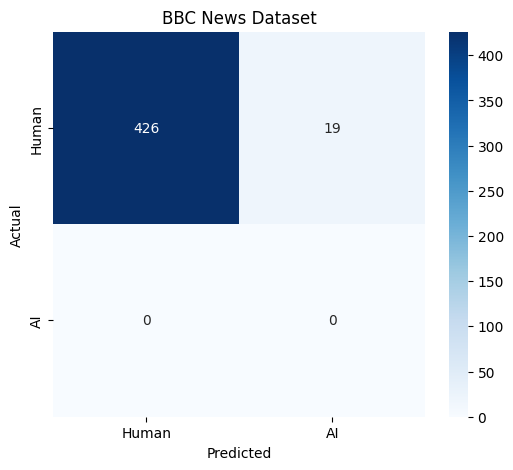

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    bbc_df["true_label"],
    bbc_df["prediction"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human","AI"],
    yticklabels=["Human","AI"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BBC News Dataset")

plt.show()

In [53]:
wrong_df = bbc_df[
    bbc_df["prediction"] != bbc_df["true_label"]
]

print("Wrong Predictions:", len(wrong_df))

wrong_df[
    ["text","prediction","confidence"]
].head(10)

Wrong Predictions: 19


,text,prediction,confidence
18,the us stock market regulator is investigating...,1,0.501383
28,a decision on whether to allow westminster to ...,1,0.577752
30,southampton are set to unveil harry redknapp a...,1,0.743704
35,the eu and us have agreed to begin talks on en...,1,0.722092
41,a major change of direction is needed in brita...,1,0.680053
75,ireland captain brian odriscoll has been ruled...,1,0.598021
132,a study of the united states at war in the pas...,1,0.982764
134,chelsea leftback wayne bridge could miss the r...,1,0.689513
151,the classic film its a wonderful life is to be...,1,0.892142
175,the us federal bureau of investigation is warn...,1,0.983804


In [54]:
# ==========================================
# Generate Probabilities
# ==========================================

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(outputs.logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # probability of AI class
        all_probs.extend(probs[:,1].cpu().numpy())

100%|██████████| 370/370 [00:27<00:00, 13.40it/s]


In [55]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probs
)

roc_auc = auc(
    fpr,
    tpr
)

print("AUC Score:", roc_auc)

AUC Score: 0.991833899666152


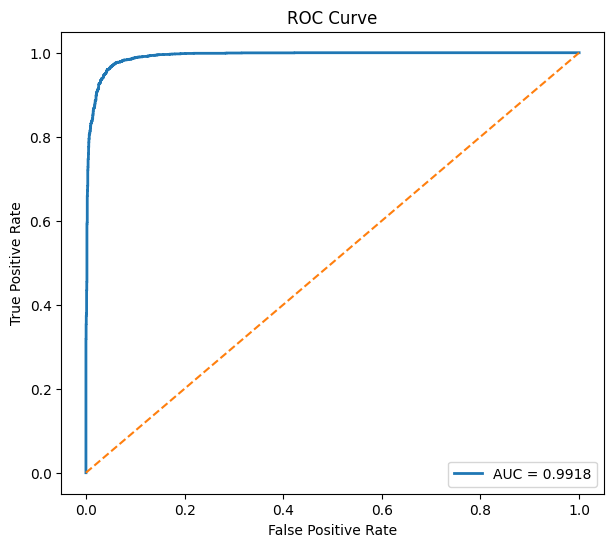

In [56]:
plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Testing with fully AI written data

In [72]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/denvermagtibay/ai-generated-essays-dataset/AI Generated Essays Dataset.csv
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/__results__.html
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/fasttext_test.txt
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/__notebook__.ipynb
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/__output__.json
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/fasttext_train.txt
/kaggle/input/notebooks/afsanaferdoussurovi/bbc-news/custom.css


In [73]:
# ==========================================================
# Load External AI Text Dataset
# ==========================================================

import pandas as pd

# Change path if necessary
DATA_PATH = "/kaggle/input/datasets/denvermagtibay/ai-generated-essays-dataset/AI Generated Essays Dataset.csv"

df_external = pd.read_csv(DATA_PATH)

print("Shape:", df_external.shape)

df_external.head()

Shape: (1460, 2)


,text,generated
0,"Machine learning, a subset of artificial intel...",1
1,"A decision tree, a prominent machine learning ...",1
2,"Education, a cornerstone of societal progress,...",1
3,"Computers, the backbone of modern technology, ...",1
4,"Chess, a timeless game of strategy and intelle...",1


In [74]:
# ==========================================================
# Check Available Columns
# ==========================================================

print(df_external.columns)

Index(['text', 'generated'], dtype='object')


In [75]:
# ==========================================================
# Create Standard Columns
# ==========================================================

external_df = pd.DataFrame()
external_df["text"] = df_external["text"]
external_df["true_label"] = df_external["generated"]
print(external_df["true_label"].value_counts())

true_label
0    1375
1      85
Name: count, dtype: int64


In [76]:
# ==========================================================
# Remove Missing Values
# ==========================================================

external_df = external_df.dropna()
external_df = external_df.reset_index(drop=True)
print("Final Shape:", external_df.shape)

Final Shape: (1460, 2)


In [79]:
# ==========================================================
# Select Only AI Texts
# ==========================================================

ai_df = external_df[external_df["true_label"] == 1]

ai_df = ai_df.reset_index(drop=True)

print("Number of AI samples:", len(ai_df))

Number of AI samples: 85


In [80]:
# ==========================================================
# Predict AI Samples
# ==========================================================

predictions, confidences = predict_batch(
    ai_df["text"]
)

In [81]:
# ==========================================================
# Save Predictions
# ==========================================================

ai_df["prediction"] = predictions
ai_df["confidence"] = confidences

# True label = AI
ai_df["true_label"] = 1

In [82]:
# ==========================================================
# AI Detection Accuracy
# ==========================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    ai_df["true_label"],
    ai_df["prediction"]
)

print(f"AI Detection Accuracy: {accuracy:.4f}")

AI Detection Accuracy: 0.5529


In [83]:
# ==========================================================
# Misclassified AI Samples
# ==========================================================

wrong_predictions = ai_df[
    ai_df["prediction"] == 0
]

print("Number of AI texts predicted as Human:")
print(len(wrong_predictions))

Number of AI texts predicted as Human:
38


In [84]:
# ==========================================================
# Show Wrong Predictions
# ==========================================================

wrong_predictions[
    ["text", "confidence"]
].head(10)

,text,confidence
1,"A decision tree, a prominent machine learning ...",0.957465
2,"Education, a cornerstone of societal progress,...",0.732934
3,"Computers, the backbone of modern technology, ...",0.849471
4,"Chess, a timeless game of strategy and intelle...",0.916009
5,"Calculus, a cornerstone of mathematical explor...",0.847529
6,"Electronics, the backbone of modern technology...",0.521739
9,"Laptops, compact and portable computing device...",0.696892
10,"Cellphones, ubiquitous in our daily lives, epi...",0.995595
13,"The electric fan, a ubiquitous household appli...",0.977736
14,"Eyeglasses, a revolutionary invention dating b...",0.997101


In [85]:
# True labels (all AI)
true_labels = np.ones(len(ai_df), dtype=int)

# Predicted labels from the model
pred_labels = ai_df["prediction"]

In [86]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        pred_labels,
        labels=[0,1],
        target_names=["Human","AI"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Human       0.00      0.00      0.00         0
          AI       1.00      0.55      0.71        85

    accuracy                           0.55        85
   macro avg       0.50      0.28      0.36        85
weighted avg       1.00      0.55      0.71        85



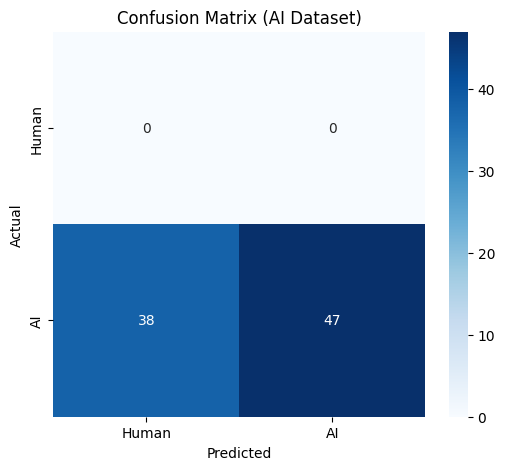

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=[0,1]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human","AI"],
    yticklabels=["Human","AI"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (AI Dataset)")

plt.show()

In [88]:
import os

print(os.listdir("/kaggle/working"))

['ai_text_detector_model', '.virtual_documents', 'best_distilbert_ai_detector.pt']


In [89]:
import shutil

shutil.copy(
    "/kaggle/working/.virtual_documents/__notebook_source__.ipynb",
    "/kaggle/working/my_notebook.ipynb"
)

'/kaggle/working/my_notebook.ipynb'